In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import nibabel as nib
import numpy as np
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import albumentations as A

from torchsummary import summary
from TransAttUnet import UNet_Attention_Transformer_Multiscale
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import accuracy_score, jaccard_score, precision_score, recall_score

In [2]:
class NSCLCNiftiDataset(Dataset):
    def __init__(self, pairs, target_size=(512, 512), is_train=False):

        self.pairs = pairs
        self.target_size = target_size
        self.is_train = is_train

        # データを増やすために、腫瘍面積上位2枚と
        # うまく予測できていない小さい腫瘍のデータを増やすために
        # 上から4枚目の3枚をつかう

        self.extended_pairs = []

        if self.is_train:
            print(f"Trainデータのスライス拡張を処理")
            for pair in pairs:
                mask_path = pair['label']
                mask_nii = nib.load(mask_path).get_fdata()

                shape = mask_nii.shape
                min_axis = np.argmin(shape)
                if min_axis == 0:
                    mask_nii = mask_nii.transpose(1, 2, 0)
                elif min_axis == 1:
                    mask_nii = mask_nii.transpose(0, 2, 1)
                
                # 全スライスの腫瘍面積計算
                num_slices = mask_nii.shape[2]
                slice_areas = [np.sum(mask_nii[:, :, i] > 0) for i in range(num_slices)]

                # 腫瘍が写ってるスライスのインデックスを、面積が大きい順にソート
                valid_slice_indices = [i for i, area in enumerate(slice_areas) if area > 0]
                sorted_indices = sorted(valid_slice_indices, key=lambda i: slice_areas[i], reverse=True)

                # 上位2枚と、4枚目(小さい腫瘍にも対応したいため)
                chosen_indices = []
                if len(sorted_indices) >= 1: chosen_indices.append(sorted_indices[0]) # 1位
                if len(sorted_indices) >= 2: chosen_indices.append(sorted_indices[1]) # 2位
                if len(sorted_indices) >= 4: chosen_indices.append(sorted_indices[3]) # 4位（インデックスは3）
                elif len(sorted_indices) >= 3: chosen_indices.append(sorted_indices[2]) # 4位がない特殊な場合は3位でカバー

                # 3枚それぞれの情報を新しいペアとして登録
                for rank, mask_idx in enumerate(chosen_indices):
                    new_pair = pair.copy()
                    new_pair['chosen_mask_idx'] = mask_idx
                    new_pair['tumor_size'] = slice_areas[mask_idx]

                    # 元の名前の末尾に、何番目のスライスか識別子を付けておく
                    new_pair['extended_name'] = f"{pair['name']}_slice_rank{rank}"
                    self.extended_pairs.append(new_pair)
        
        else:
            # Testデータは最大スライス1枚のみ
            for pair in pairs:
                mask_path = pair['label']
                mask_nii = nib.load(mask_path).get_fdata()

                # 軸の修正
                shape = mask_nii.shape
                min_axis = np.argmin(shape)
                if min_axis == 0:
                    mask_nii = mask_nii.transpose(1, 2, 0)
                elif min_axis == 1:
                    mask_nii = mask_nii.transpose(0, 2, 1)
                
                # 全スライスの腫瘍面積計算
                num_slices = mask_nii.shape[2]
                slice_areas = [np.sum(mask_nii[:, :, i] > 0) for i in range(num_slices)]
                max_mask_idx = int(np.argmax(slice_areas))

                new_pair = pair.copy()
                new_pair['chosen_mask_idx'] = max_mask_idx
                new_pair['tumor_size'] = slice_areas[max_mask_idx]
                new_pair['extended_name'] = pair['name']
                self.extended_pairs.append(new_pair)

        # DA定義
        # if self.is_train:
        #     self.da_transform = A.Compose([
        #         A.HorizontalFlip(p=0.5),
        #         A.VerticalFlip(p=0.5),
        #         A.RandomRotate90(p=0.5),
        #         A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=30, p=0.5),
        #     ])
    
    def __len__(self):
        return len(self.extended_pairs)
    
    def __getitem__(self, idx):
        pair = self.extended_pairs[idx]
        file_id = pair['extended_name']
        img_path = pair['image']
        mask_path = pair['label']
        max_mask_idx = pair['chosen_mask_idx']
        tumor_size_2d = pair['tumor_size']

        img_nii = nib.load(img_path).get_fdata()
        mask_nii = nib.load(mask_path).get_fdata()

        def fix_slice_axis(data):
            shape = data.shape
            # 3つの軸の中で、512より小さい（枚数と思われる）軸のインデックスを探す
            min_axis = np.argmin(shape)
            if min_axis == 0:   # (Slices, H, W) -> (H, W, Slices)
                return data.transpose(1, 2, 0)
            elif min_axis == 1: # (H, Slices, W) -> (H, W, Slices)
                return data.transpose(0, 2, 1)
            return data         # すでに (H, W, Slices)

        img_nii = fix_slice_axis(img_nii)
        mask_nii = fix_slice_axis(mask_nii)

        # --- 【ここが重要】画像側のスライス枚数に合わせてリスケールする ---
        num_slices_mask = mask_nii.shape[2]
        num_slices_img = img_nii.shape[2]
        # 画像とマスクの枚数が違う場合でも、相対的な位置を計算する
        z_ratio = num_slices_img / num_slices_mask
        max_img_idx = int(max_mask_idx * z_ratio)
        
        # 最後に念のためガードレールをかける
        max_img_idx = min(max_img_idx, num_slices_img - 1)

        img_slice = img_nii[:, :, max_img_idx]
        mask_slice = mask_nii[:, :, max_mask_idx]

        # CT値の正規化(?わからん -1000~400程度にクリップ)
        # 肺の微細な構造を鮮明に観察するための肺野条件らしい
        img_slice = np.clip(img_slice, -1000, 400)
        #0-1の正規化
        img_slice = (img_slice + 1000) / 1400

        # DA
        # if self.is_train:
        #     augmented = self.da_transform(image=img_slice, mask=mask_slice)
        #     img_slice = augmented['image']
        #     mask_slice = augmented['mask']

        # リサイズとテンソル化
        img_tensor = torch.from_numpy(img_slice).float().unsqueeze(0) # [1, H, W]
        mask_tensor = torch.from_numpy(mask_slice).float().unsqueeze(0)

        img_tensor = F.interpolate(img_tensor.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False).squeeze(0)
        mask_tensor = F.interpolate(mask_tensor.unsqueeze(0), size=self.target_size, mode='nearest').squeeze(0)
        # Datasetの __getitem__ 内
        #img_slice = img_nii[:, :, max_img_idx] # 135番が抜かれる
        #print(f"DEBUG: {file_id} のスライス {max_img_idx} を抽出しました。形: {img_slice.shape}")

        # ここで一度表示して、専用コードの135番と見比べる
        #import matplotlib.pyplot as plt
        #plt.imshow(img_slice, cmap='gray')
        #plt.title("Dataset抽出直後 (Resize前)")
        #plt.show()

        # スライスのピクセル数(腫瘍面積)

        return img_tensor, mask_tensor, file_id, tumor_size_2d

if __name__ == '__main__':
    root_dir = '/workspace/NSCLC_NIfTI2'

    images_dir = '/workspace/NSCLC_NIfTI2/imagesTr'
    labels_dir = '/workspace/NSCLC_NIfTI2/labelsTr/Neoplasm_Primary'

    # 全てのファイル名を取得
    all_images = sorted([f for f in os.listdir(images_dir) if f.endswith('.nii.gz')])

    # 画像とラベルのフルパスのペアをリストに
    valid_pairs = []
    for f in all_images:
        img_path = os.path.join(images_dir, f)
        lbl_path = os.path.join(labels_dir, f)

        # ラベルが存在するか
        if os.path.exists(lbl_path):
            # ペアを辞書形式で保存
            valid_pairs.append({
                'image': img_path,
                'label': lbl_path,
                'name': f
            })
    print(f"有効なペア数: {len(valid_pairs)}")

    # train 8  test 2で分割
    train_pairs, test_pairs = train_test_split(valid_pairs, test_size=0.2, random_state=42)

    print(f"--- データ分割完了 ---")

    print(f"学習用ペア数: {len(train_pairs)}")
    print(f"テスト用ペア数: {len(test_pairs)}")

    # 確認：テスト用の1番目のデータが正しくペアになっているか
    print(f"\n[確認] テスト用データの1番目:")
    print(f"名前: {test_pairs[0]['name']}")
    print(f"画像: {test_pairs[0]['image']}")
    print(f"ラベル: {test_pairs[0]['label']}")

    # Datasetのインスタンス化
    train_dataset = NSCLCNiftiDataset(train_pairs, is_train=True)
    test_dataset = NSCLCNiftiDataset(test_pairs, is_train=False)

    print(f"\n--- Dataset作成完了 ---")
    print(f"学習用: {len(train_dataset)}件, テスト用: {len(test_dataset)}件")

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    print(f"DataLoader準備完了")

    # 動作確認
    img, mask, name, size = train_dataset[0]
    print(f"\n[動作確認成功]")
    print(f"患者ID {name}")
    print(f"画像の形: {img.shape}")
    print(f"マスクの形: {mask.shape}")


有効なペア数: 421
--- データ分割完了 ---
学習用ペア数: 336
テスト用ペア数: 85

[確認] テスト用データの1番目:
名前: LUNG1-147.nii.gz
画像: /workspace/NSCLC_NIfTI2/imagesTr/LUNG1-147.nii.gz
ラベル: /workspace/NSCLC_NIfTI2/labelsTr/Neoplasm_Primary/LUNG1-147.nii.gz
Trainデータのスライス拡張を処理

--- Dataset作成完了 ---
学習用: 1004件, テスト用: 85件
DataLoader準備完了

[動作確認成功]
患者ID LUNG1-133.nii.gz_slice_rank0
画像の形: torch.Size([1, 512, 512])
マスクの形: torch.Size([1, 512, 512])


Trainデータのスライス拡張を処理


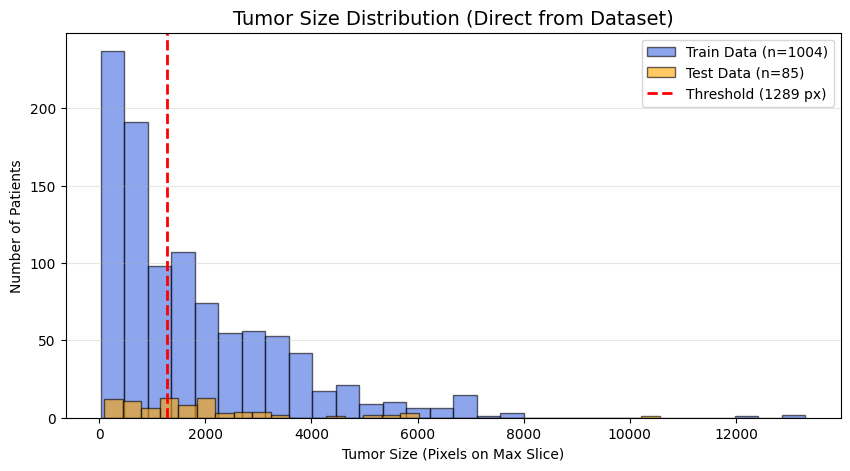

割り出された閾値: 1289 ピクセル


In [3]:
# trainとtestを腫瘍の大きさ(大, 小)で分ける
# 測定用のデータセット
train_measure_dataset = NSCLCNiftiDataset(train_pairs, is_train=True)
test_measure_dataset = NSCLCNiftiDataset(test_pairs, is_train=False)

# Datasetから計算済みのサイズだけ回収(最大面積の腫瘍とってるため)
train_sizes = np.array([train_measure_dataset[i][3]for i in range(len(train_measure_dataset))])
test_sizes = np.array([test_measure_dataset[i][3] for i in range(len(test_measure_dataset))])
all_sizes = np.concatenate([train_sizes, test_sizes])

# 閾値(中央値)の決定とヒストグラム
threshold = np.median(all_sizes)

plt.figure(figsize=(10, 5))
plt.hist(train_sizes, bins=30, color='royalblue', alpha=0.6, label=f'Train Data (n={len(train_sizes)})', edgecolor='black')
plt.hist(test_sizes, bins=30, color='orange', alpha=0.6, label=f'Test Data (n={len(test_sizes)})', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Threshold ({int(threshold)} px)')
plt.title('Tumor Size Distribution (Direct from Dataset)', fontsize=14)
plt.xlabel('Tumor Size (Pixels on Max Slice)')
plt.ylabel('Number of Patients')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"割り出された閾値: {int(threshold)} ピクセル")


In [4]:
# 3倍に拡張されているextended_pairsを直接使って、閾値で仕分ける
train_extended_pairs_large = [p for p in train_measure_dataset.extended_pairs if p['tumor_size'] >= threshold]
train_extended_pairs_small = [p for p in train_measure_dataset.extended_pairs if p['tumor_size'] < threshold]

test_extended_pairs_large = [p for p in test_measure_dataset.extended_pairs if p['tumor_size'] >= threshold]
test_extended_pairs_small = [p for p in test_measure_dataset.extended_pairs if p['tumor_size'] < threshold]

# 仕分けたリストを使って、新しくDatasetを作る
# trainはすでに拡張済みのリストを渡すため、これ以上増えないように is_train=False でインスタンス化
train_ds_large = NSCLCNiftiDataset([], is_train=False)  # 空で初期化
train_ds_large.extended_pairs = train_extended_pairs_large

train_ds_small = NSCLCNiftiDataset([], is_train=False)
train_ds_small.extended_pairs = train_extended_pairs_small

test_ds_large = NSCLCNiftiDataset([], is_train=False)
test_ds_large.extended_pairs = test_extended_pairs_large

test_ds_small = NSCLCNiftiDataset([], is_train=False)
test_ds_small.extended_pairs = test_extended_pairs_small


# サイズ別DataLoaderの作成
batch_size = 8
train_loader_large = DataLoader(train_ds_large, batch_size=batch_size, shuffle=True)
train_loader_small = DataLoader(train_ds_small, batch_size=batch_size, shuffle=True)
test_loader_large = DataLoader(test_ds_large, batch_size=batch_size, shuffle=False)
test_loader_small = DataLoader(test_ds_small, batch_size=batch_size, shuffle=False)


# 拡張された後の正確な件数をプリント
print(f"train_loader_large: {len(train_ds_large)}件 / test_loader_large: {len(test_ds_large)}件")
print(f"train_loader_small: {len(train_ds_small)}件 / test_loader_small: {len(test_ds_small)}件")

train_loader_large: 495件 / test_loader_large: 50件
train_loader_small: 509件 / test_loader_small: 35件


In [3]:
# 何件かのデータを取り出して、マスクに含まれるユニークな（独自の）値を調べる
print("--- マスクデータの値（Unique Values）チェック ---")

# とりあえず最初の5件をチェック
for i in range(min(5, len(train_dataset))):
    img, mask, name = train_dataset[i]
    
    # マスクのテンソルから、重複を除いた値（ユニーク値）を抽出
    unique_values = torch.unique(mask).tolist()
    
    print(f"データ [{i}] (患者ID: {name}):")
    print(f"  マスクに含まれる値: {unique_values}")
    
    # 理想的な状態かどうかの判定
    if unique_values == [0.0, 1.0] or unique_values == [0.0] or unique_values == [1.0]:
        print("  => ✨ 正常：0 と 1（またはどちらか片方）だけで構成されています。")
    else:
        print("  => ⚠️ 注意：0 と 1 以外の値（2や255など）が含まれています！二値化が必要です。")
    print("-" * 40)

--- マスクデータの値（Unique Values）チェック ---
データ [0] (患者ID: LUNG1-133.nii.gz):
  マスクに含まれる値: [0.0, 1.0]
  => ✨ 正常：0 と 1（またはどちらか片方）だけで構成されています。
----------------------------------------
データ [1] (患者ID: LUNG1-032.nii.gz):
  マスクに含まれる値: [0.0, 1.0]
  => ✨ 正常：0 と 1（またはどちらか片方）だけで構成されています。
----------------------------------------
データ [2] (患者ID: LUNG1-085.nii.gz):
  マスクに含まれる値: [0.0, 1.0]
  => ✨ 正常：0 と 1（またはどちらか片方）だけで構成されています。
----------------------------------------
データ [3] (患者ID: LUNG1-291.nii.gz):
  マスクに含まれる値: [0.0, 1.0]
  => ✨ 正常：0 と 1（またはどちらか片方）だけで構成されています。
----------------------------------------
データ [4] (患者ID: LUNG1-410.nii.gz):
  マスクに含まれる値: [0.0, 1.0]
  => ✨ 正常：0 と 1（またはどちらか片方）だけで構成されています。
----------------------------------------


In [5]:
# BCEとDice Lossを混ぜる
class MixLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(MixLoss, self).__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()
    
    def forward(self, outputs, targets):
        targets  = targets.float()
        
        probs = torch.sigmoid(outputs)
        
        # 計算不可能にならないように範囲指定
        probs = torch.clamp(probs, 1e-7, 1.0 - 1e-7)

        # BCE Lossの計算
        bce_loss = self.bce(probs, targets)
        
        # Dice Lossの計算
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()

        dice_loss = 1.0 - ((2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth))

        total_loss = 0.5 * bce_loss + 0.5 * dice_loss

        return total_loss


In [6]:
# 学習設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = UNet_Attention_Transformer_Multiscale(n_channels=1, n_classes=1).to(device)

# 重みロード
model.load_state_dict(torch.load('/workspace/TransAttUnet/model/checkpoints/model_epoch_50.pth')) # 保存されたファイル名

#最適化アルゴリズム 1e-4
optimizer = optim.SGD(model.parameters(), lr=1e-5, momentum=0.9, weight_decay=1e-4)
# 30エポックごとに学習率を0.1倍に
# scheduler = StepLR(optimizer, step_size=30, gamma=0.1)
# 損失関数
criterion = MixLoss()

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_epochs = 20

train_loss_history = []
val_loss_history = []

In [7]:
model.to(device)
summary(model, input_size=(1, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]             640
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
        DoubleConv-7         [-1, 64, 256, 256]               0
         MaxPool2d-8         [-1, 64, 128, 128]               0
            Conv2d-9        [-1, 128, 128, 128]          73,856
      BatchNorm2d-10        [-1, 128, 128, 128]             256
             ReLU-11        [-1, 128, 128, 128]               0
           Conv2d-12        [-1, 128, 128, 128]         147,584
      BatchNorm2d-13        [-1, 128, 128, 128]             256
             ReLU-14        [-1, 128, 1

In [ ]:
print("学習を開始...")
# 勾配蓄積回数
accumulation_steps = 3

for epoch in range(num_epochs):
    # 学習
    model.train()
    train_loss = 0.0

    # 蓄積を開始する前に勾配リセット
    optimizer.zero_grad()

    for i, (images, masks, file_ids, sizes) in enumerate(train_loader):
        images, masks = images.to(device), masks.to(device)

        # 予測と計算
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Lossを蓄積回数で割る
        loss_scaled = loss / accumulation_steps

        # 勾配の計算
        loss_scaled.backward()
        
        # 重みの更新
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad()

        train_loss += loss.item()

    avg_train_loss = train_loss /len(train_loader)

        # 検証(テストデータでの評価)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks, file_ids, sizes in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, masks)
            val_loss += v_loss.item()

    avg_val_loss = val_loss / len(test_loader)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)
    #scheduler.step()
    #print(f"次のエポック学習率: {scheduler.get_last_lr()[0]}")

    # 進捗を表示
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # モデルの保存
    os.makedirs('checkpoints', exist_ok=True)

    # 10エポックごとに重みを保存
    if (epoch + 1) % 10 == 0:
        save_path = f"checkpoints/model_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), save_path)
        print(f"--- モデルを保存しました: {save_path}")

print("すべての学習が完了しました。")

学習を開始...
Epoch [1/100] Train Loss: 0.4526, Val Loss: 0.4408
Epoch [2/100] Train Loss: 0.4449, Val Loss: 0.4338
Epoch [3/100] Train Loss: 0.4367, Val Loss: 0.4261
Epoch [4/100] Train Loss: 0.4297, Val Loss: 0.4155
Epoch [5/100] Train Loss: 0.4217, Val Loss: 0.4149
Epoch [6/100] Train Loss: 0.4146, Val Loss: 0.4173
Epoch [7/100] Train Loss: 0.4072, Val Loss: 0.4007
Epoch [8/100] Train Loss: 0.3990, Val Loss: 0.3899
Epoch [9/100] Train Loss: 0.3904, Val Loss: 0.3839
Epoch [10/100] Train Loss: 0.3829, Val Loss: 0.3768
--- モデルを保存しました: checkpoints/model_epoch_10.pth
Epoch [11/100] Train Loss: 0.3737, Val Loss: 0.3673
Epoch [12/100] Train Loss: 0.3648, Val Loss: 0.3590
Epoch [13/100] Train Loss: 0.3563, Val Loss: 0.3503
Epoch [14/100] Train Loss: 0.3464, Val Loss: 0.3445
Epoch [15/100] Train Loss: 0.3386, Val Loss: 0.3508
Epoch [16/100] Train Loss: 0.3290, Val Loss: 0.3297
Epoch [17/100] Train Loss: 0.3194, Val Loss: 0.3224
Epoch [18/100] Train Loss: 0.3094, Val Loss: 0.3176
Epoch [19/100] Tr

KeyboardInterrupt: 

30 80でとまった

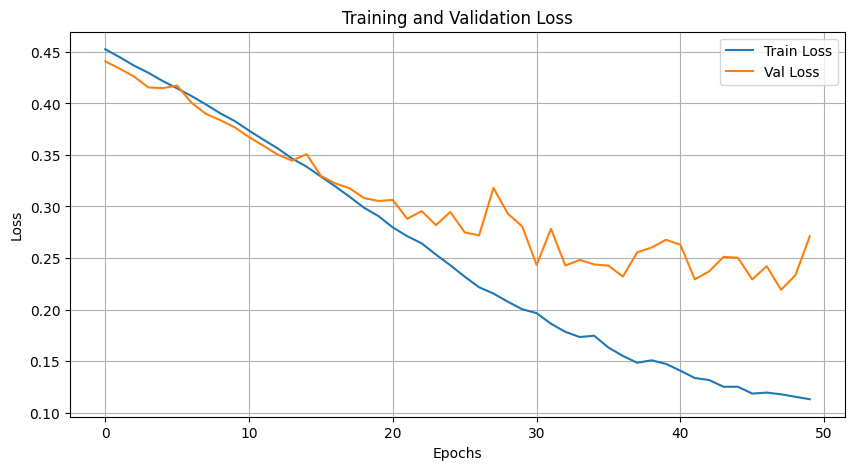

In [8]:
# グラフの描画
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [7]:
def visualize_10_patients(model, test_loader, device, save_path="results_10_patients.png"):
    # 保存した重み
    #model_path = '/workspace/TransAttUnet/model/checkpoints/model_epoch_50.pth'
    model_path = '/workspace/checkpoints_large/model_epoch_20.pth'

    missing_keys, unexpected_keys = model.load_state_dict(torch.load(model_path), strict=True)
    print(f"足りない部品: {missing_keys}")
    print(f"余計な部品: {unexpected_keys}")
    model.eval()
    patients_count = 0
    max_patients = 10

    # グラフサイズ(必ず10行3列で作る)
    fig, axes = plt.subplots(max_patients, 3, figsize=(15, 5 * max_patients))

    with torch.no_grad():
        for i, data in enumerate(test_loader):
            if patients_count >= max_patients:
                break

            images, masks, file_ids, sizes = data

            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)

            current_batch_size = images.size(0)
            for b in range(current_batch_size):
                if patients_count >= max_patients:
                    break

                # インデント [0] から [b] に変更してバッチ内の全データを回収
                img = images[b, 0].cpu().numpy()
                gt = masks[b, 0].cpu().numpy()
                pred = preds[b, 0].cpu().numpy()
                p_id = file_ids[b] # 患者名
                t_size = sizes[b].item()

                # 描画
                # CT画像
                axes[patients_count, 0].imshow(img, cmap='gray')
                axes[patients_count, 0].set_title(f"Patient: {p_id} (Size: {int(t_size)}px)")
                axes[patients_count, 0].axis('off')

                # Ground Truth
                axes[patients_count, 1].imshow(img, cmap='gray')
                masked_gt = np.ma.masked_where(gt == 0, gt)
                axes[patients_count, 1].imshow(masked_gt, cmap='Reds', alpha=.4, vmin=0, vmax=1)
                axes[patients_count, 1].set_title("Ground Truth")
                axes[patients_count, 1].axis('off')

                # Prediction (Overlay)
                axes[patients_count, 2].imshow(img, cmap='gray')
                mask_pred = (pred > 0.5).astype(float)

                # 背景を透明にするマスク処理
                masked_pred = np.ma.masked_where(mask_pred == 0, mask_pred)
                axes[patients_count, 2].imshow(masked_pred, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
                axes[patients_count, 2].set_title(f"Prediction (Max: {pred.max():.4f})")
                axes[patients_count, 2].axis('off')
                
                # ここでカウントアップ
                patients_count += 1
        
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close() # メモリ解放
        print(f"Saved visualization to {save_path} (Total: {patients_count} patients)")    

In [8]:
# 関数の呼び出し
# ここで分けた画像を呼ぶ(2つ)
visualize_10_patients(model, test_loader_large, device, save_path="final_analysis_large_10_patients.png")

# グラフ表示
plt.show()

足りない部品: []
余計な部品: []
Saved visualization to final_analysis_large_10_patients.png (Total: 10 patients)


In [16]:
visualize_10_patients(model, test_loader_small, device, save_path="final_analysis_small_10_patients.png")

# グラフ表示
plt.show()

足りない部品: []
余計な部品: []
Saved visualization to final_analysis_small_10_patients.png (Total: 10 patients)


In [9]:
# 評価指標の計算
model.eval()

dice_list = []
iou_list = []
acc_list = []
rec_list = []
pre_list = []

# テストデータを回してデータを集める
with torch.no_grad():
    # ここでlargeかsmallか変える
    for data in test_loader_small:
        # データローダーの形式に合わせて分解
        if len(data) == 3:
            images, masks, _ = data
        else:
            images, masks, _, sizes= data
        
        # 予測させて、2値(0か1の白黒)に変換
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        # バッチから画像1枚ずつ取り出す
        for j in range(images.size(0)):
            # 予測
            p = preds[j].cpu().numpy().flatten()
            # 正解
            t = masks[j].numpy().flatten()

            # 画像1枚分だけ
            p_score = precision_score(t, p, zero_division=0)
            r_score = recall_score(t, p, zero_division=0)
            i_score = jaccard_score(t, p, zero_division=0)
            a_score = accuracy_score(t, p)

            d_score = (2 * i_score) / (i_score + 1) if i_score > 0 else 0.0

            # 腫瘍なしなら100%
            if np.sum(t) == 0 and np.sum(p) == 0:
                d_score = 1.0
                i_score = 1.0
            
            # リストに保存
            pre_list.append(p_score)
            rec_list.append(r_score)
            iou_list.append(i_score)
            acc_list.append(a_score)
            dice_list.append(d_score)

# 平均をとる ACC(精度), REC(再現率), PRE(適合率)
print(f"mean DICE: {np.mean(dice_list) * 100:.2f}%")
print(f"mean IoU : {np.mean(iou_list) * 100:.2f}%")
print(f"mean ACC : {np.mean(acc_list) * 100:.2f}%")
print(f"mean REC : {np.mean(rec_list) * 100:.2f}%")
print(f"mean PRE : {np.mean(pre_list) * 100:.2f}%")


mean DICE: 42.29%
mean IoU : 34.14%
mean ACC : 99.82%
mean REC : 41.28%
mean PRE : 53.42%


In [14]:
# テストデータを1バッチだけ取り出す
images, masks, file_ids = next(iter(test_loader))
model.eval()

with torch.no_grad():
    raw_outputs = model(images.to(device))

# 出力の数とサイズをすべて洗い出す
if isinstance(raw_outputs, (list, tuple)):
    print(f"出力されたお弁当箱の数: {len(raw_outputs)} 個")
    for idx, out in enumerate(raw_outputs):
        print(f"  ・ outputs[{idx}] の形 (Shape): {out.shape}")
else:
    print(f"単一の出力です。形 (Shape): {raw_outputs.shape}")
    
print(f"正解マスク (masks) の形: {masks.shape}")

単一の出力です。形 (Shape): torch.Size([8, 1, 512, 512])
正解マスク (masks) の形: torch.Size([8, 1, 512, 512])
